In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("Netflix_stock_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2002-05-23,0.119643,0.124286,0.114571,0.115643,1047900000
1,2002-05-24,0.121000,0.122500,0.119714,0.121429,111048000
2,2002-05-28,0.115714,0.123214,0.115714,0.121357,66094000
3,2002-05-29,0.110357,0.116429,0.108571,0.116429,67578000
4,2002-05-30,0.107143,0.110786,0.107143,0.110786,101542000


In [4]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [5]:
df['Date'] = pd.to_datetime(df['Date'])

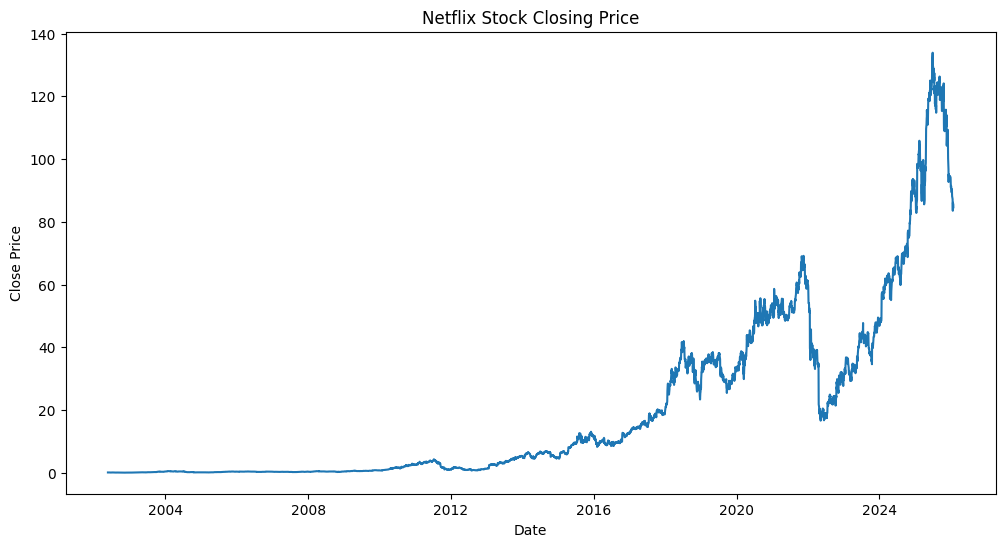

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'])

plt.title("Netflix Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.show()

In [7]:
df['Day'] = np.arange(len(df))

In [9]:
X = df[['Day']]
y = df['Close']

In [10]:
split_index = int(len(df) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [11]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
predictions = model.predict(X_test)

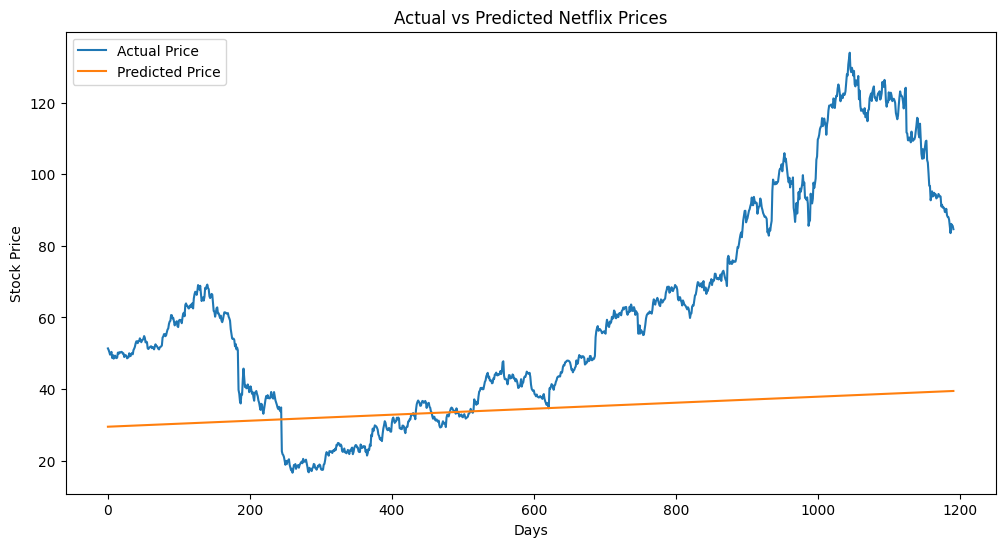

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.title("Actual vs Predicted Netflix Prices")
plt.xlabel("Days")
plt.ylabel("Stock Price")

plt.legend()

plt.show()

In [14]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 29.233214351973547


In [15]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)

print("R2 Score:", score)

R2 Score: -0.6138399007127289
